In [2]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
train_df = pd.read_csv('data_train.csv', sep="\t")
test_df = pd.read_csv('data_test.csv', sep="\t")

In [5]:
X = torch.Tensor(np.array(train_df.iloc[:,:-1])).to(device)
y = X.to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [6]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,X.shape[1]),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.000945 | Val MSE: 0.000964
Epoch 20 | Train MSE: 0.000945 | Val MSE: 0.000964
Epoch 40 | Train MSE: 0.000945 | Val MSE: 0.000965
Epoch 60 | Train MSE: 0.000944 | Val MSE: 0.000965
Epoch 80 | Train MSE: 0.000944 | Val MSE: 0.000965
Epoch 100 | Train MSE: 0.000944 | Val MSE: 0.000965
Epoch 120 | Train MSE: 0.000943 | Val MSE: 0.000965
Epoch 140 | Train MSE: 0.000944 | Val MSE: 0.000965
Epoch 160 | Train MSE: 0.000942 | Val MSE: 0.000964
Epoch 180 | Train MSE: 0.000942 | Val MSE: 0.000965
Epoch 200 | Train MSE: 0.000942 | Val MSE: 0.000965
Epoch 220 | Train MSE: 0.000942 | Val MSE: 0.000964
Epoch 240 | Train MSE: 0.000941 | Val MSE: 0.000965
Epoch 260 | Train MSE: 0.000941 | Val MSE: 0.000965
Epoch 280 | Train MSE: 0.000941 | Val MSE: 0.000965
Epoch 300 | Train MSE: 0.000940 | Val MSE: 0.000965
Epoch 320 | Train MSE: 0.000940 | Val MSE: 0.000964
Epoch 340 | Train MSE: 0.000939 | Val MSE: 0.000964
Epoch 360 | Train MSE: 0.000939 | Val MSE: 0.000965
Epoch 380 | Train

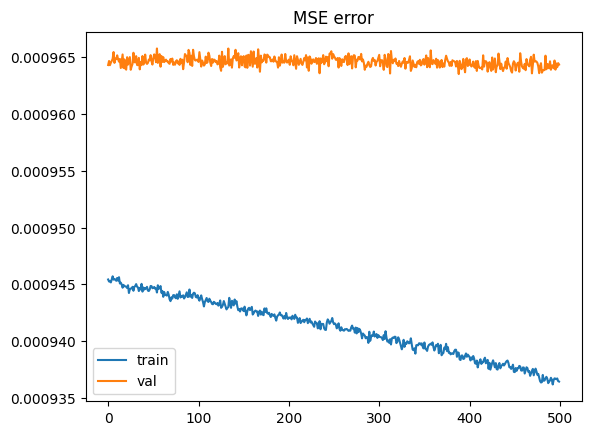

In [19]:
epochs = 500  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%20==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

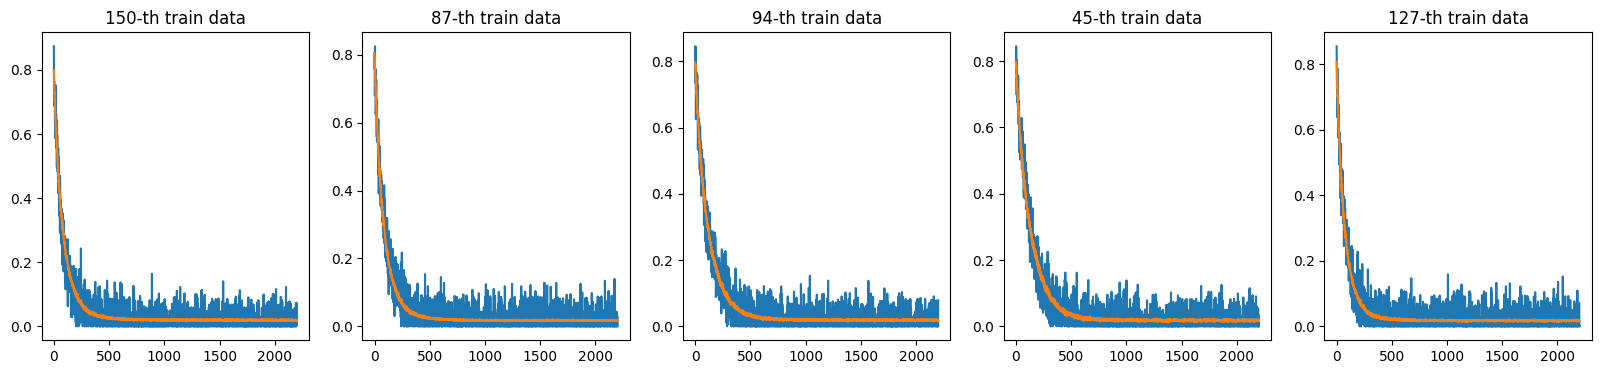

In [8]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

fig, ax = plt.subplots(1,5, figsize=(20,4))
for i,j in enumerate(np.random.randint(1,len(Xval),5)):
    ax[i].plot(Xval.squeeze().detach().cpu().numpy()[j])
    ax[i].plot(y_pred[j])
    # ax[i].plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same")) #smoothed-out y_pred, edge-aware
    ax[i].set_title(f"{j}-th train data")
plt.show()

In [9]:
import pywt
def DWTdenoise(noisy, wvlet='db6', level=6, mode='soft'):
    # DWT decomposition
    coeffs = pywt.wavedec(noisy, wvlet, level=level)#, mode='smooth')
    cA, cD = coeffs[0], coeffs[1:]

    # Estimate noise level (MAD)
    sigma = np.median(np.abs(cD[-1])) / 0.6745 *2
    T = sigma * np.sqrt(2 * np.log(len(noisy)))

    # Thresholding
    coeffs_thresh = [cA] + [pywt.threshold(cd, T, mode=mode) for cd in cD]

    # Return denoised signal
    return pywt.waverec(coeffs_thresh, wvlet), coeffs_thresh

127-th train data


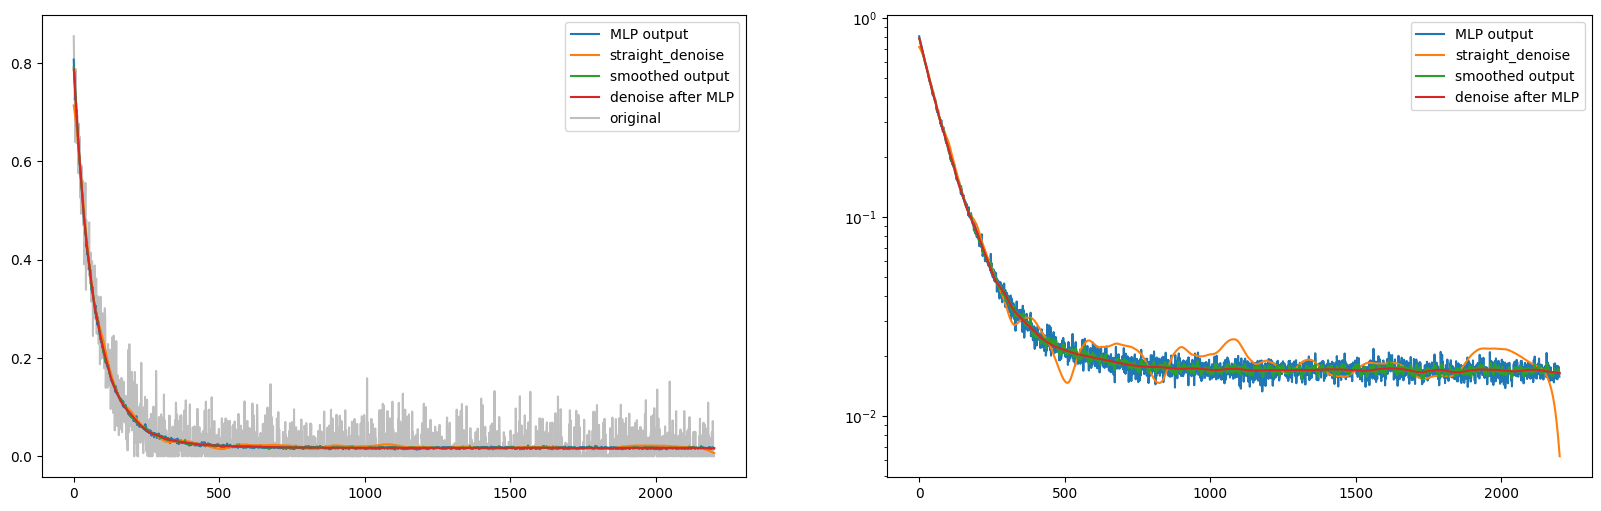

In [16]:
y_pred_DWTj,_ = DWTdenoise(y_pred[j], wvlet='db6', level=6)
y_DWTj     ,_ = DWTdenoise(Xval.squeeze().detach().cpu().numpy()[j], wvlet='db6', level=6)

fig, (ax0,ax1) = plt.subplots(1,2, figsize=(20,6))

ax0.plot(y_pred[j], label="MLP output")
ax0.plot(y_DWTj, label="straight_denoise")
ax0.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax0.plot(y_pred_DWTj, label="denoise after MLP")
ax0.plot(Xval.squeeze().detach().cpu().numpy()[j], label="original", zorder=0, c='gray', alpha=.5)
# ax.yscale('log')
ax0.legend();

ax1.plot(y_pred[j], label="MLP output")
ax1.plot(y_DWTj, label="straight_denoise")
ax1.plot(np.convolve(y_pred[j],np.ones(5), mode='same')/np.convolve(np.ones_like(y_pred[j]),np.ones(5), mode="same"), label="smoothed output")
ax1.plot(y_pred_DWTj, label="denoise after MLP")
ax1.set_yscale('log')
ax1.legend();
print(f"{j}-th train data")
plt.show()

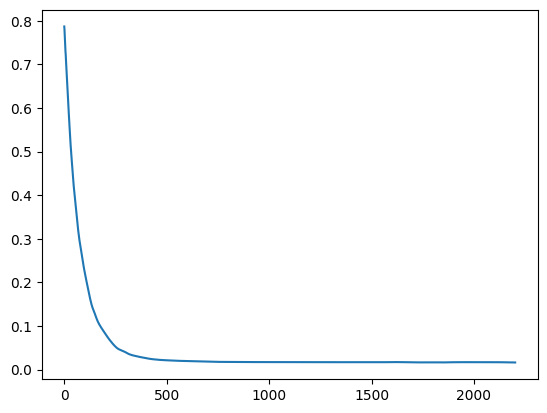

In [18]:
plt.plot(y_pred_DWTj, label="denoise after MLP")